# Plant Disease Detection
**Metode:** Classical Preprocessing Pipeline + EfficientNetB0 Transfer Learning  
**Baseline:** SVM + LBP / SVM + HOG (opsional, diatur lewat `RUN_BASELINE`)

**Nama :** M. Raditya Faturrahman  
**NIM  :** 1304221050  
**Mata Kuliah :** Pemrosesan Citra Digital (CII4F3)


---
## Import Library

In [1]:
import os
import glob
import warnings
import shutil
import numpy as np
import cv2

from skimage import feature as skfeature
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print('Library berhasil diimpor.')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

2026-06-14 05:32:09.407082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781415129.628286      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781415129.689131      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781415130.216176      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781415130.216217      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781415130.216221      23 computation_placer.cc:177] computation placer alr

Library berhasil diimpor.
TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## Deteksi Dataset & Parameter

In [2]:
def find_color_dir(base='/kaggle/input'):
    for root, dirs, _ in os.walk(base):
        if 'color' in dirs:
            candidate = os.path.join(root, 'color')
            subdirs = [d for d in os.listdir(candidate)
                       if os.path.isdir(os.path.join(candidate, d))]
            if len(subdirs) >= 10:
                return candidate
    return None

RAW_PATH = find_color_dir()

if RAW_PATH is None:
    print('[!] Dataset tidak ditemukan. Tambahkan via + Add Data → PlantVillage Dataset')
    print('Isi /kaggle/input saat ini:')
    for item in os.listdir('/kaggle/input'):
        print(f'  - {item}')
    raise FileNotFoundError('Dataset tidak ditemukan.')

kelas = sorted([d for d in os.listdir(RAW_PATH)
                if os.path.isdir(os.path.join(RAW_PATH, d))])
print(f'Dataset : {RAW_PATH}')
print(f'Kelas   : {len(kelas)}')

IMG_SIZE        = 224
IMG_SIZE_SVM    = 64
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 5
EPOCHS_FINETUNE = 10
LR_FROZEN       = 1e-4
LR_FINETUNE     = 1e-5
NUM_CLASSES     = len(kelas)
N_LIMIT_SVM     = 300
SEED            = 42
CACHE_PATH      = '/kaggle/working/plantvillage_processed'
MODEL_PATH      = '/kaggle/working/efficientnetb0_plantvillage.h5'
RUN_BASELINE    = False

print(f'NUM_CLASSES : {NUM_CLASSES}')
print(f'EPOCHS      : {EPOCHS_FROZEN} frozen + {EPOCHS_FINETUNE} fine-tune')

Dataset : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Kelas   : 38
NUM_CLASSES : 38
EPOCHS      : 5 frozen + 10 fine-tune


---
## Pre-processing Klasik

Tahapan: Gaussian → Median → CLAHE → Contrast Stretch → HSV Masking  
**Catatan:** HSV masking punya fallback — jika hasil masking terlalu gelap (gambar daun sakit/menguning),
gambar dikembalikan tanpa masking agar tidak menjadi all-black yang menyebabkan NaN loss.

In [3]:
def preprocess_image(img_bgr):
    # 1. Gaussian blur
    img = cv2.GaussianBlur(img_bgr, (5, 5), sigmaX=1)
    # 2. Median blur
    img = cv2.medianBlur(img, 3)
    # 3. CLAHE pada channel L
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)
    # 4. Contrast stretching
    img_f = img.astype(np.float32)
    img = ((img_f - img_f.min()) / (img_f.max() - img_f.min() + 1e-8) * 255).astype(np.uint8)
    # 5. HSV masking (range diperlebar, ada fallback)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([20, 20, 20]), np.array([100, 255, 255]))
    mask = cv2.erode(mask,  np.ones((3, 3), np.uint8), iterations=1)
    mask = cv2.dilate(mask, np.ones((5, 5), np.uint8), iterations=2)
    masked = cv2.bitwise_and(img, img, mask=mask)
    # Fallback: jika > 90% pixel hitam, kembalikan tanpa masking
    if masked.mean() < 8.0:
        return img
    return masked


def load_and_preprocess(img_path, size=IMG_SIZE_SVM):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = preprocess_image(img)
    img = cv2.resize(img, (size, size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0

print('Fungsi pre-processing terdefinisi.')

Fungsi pre-processing terdefinisi.


---
## Visualisasi Pre-processing

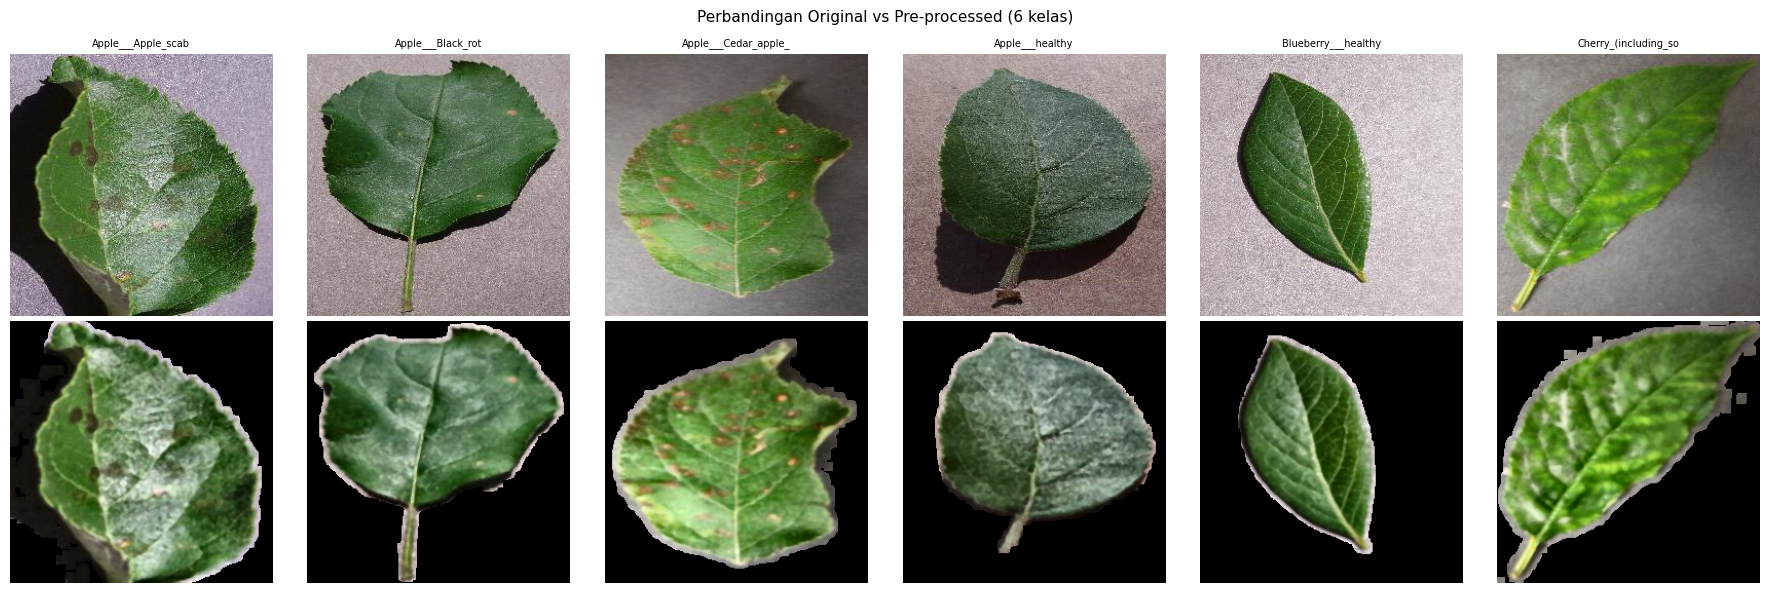

In [4]:
# Tampilkan 6 contoh dari kelas berbeda
sample_classes = kelas[:6]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, cls in enumerate(sample_classes):
    paths = (glob.glob(os.path.join(RAW_PATH, cls, '*.jpg')) +
             glob.glob(os.path.join(RAW_PATH, cls, '*.JPG')))
    if not paths: continue
    img_bgr = cv2.imread(paths[0])
    img_raw = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pre = cv2.cvtColor(preprocess_image(img_bgr), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_raw);  axes[0, i].set_title(cls[:20], fontsize=7); axes[0, i].axis('off')
    axes[1, i].imshow(img_pre);  axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',     fontsize=9)
axes[1, 0].set_ylabel('Pre-processed', fontsize=9)
plt.suptitle('Perbandingan Original vs Pre-processed (6 kelas)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Cache Pre-processed Images

Pre-processing dijalankan **sekali** ke SSD lokal Kaggle.  
Training baca dari cache → tidak ada operasi berat per-batch.  
Estimasi: **~10–15 menit** (satu kali saja).

In [5]:
def cache_is_valid(cache_dir, expected_classes):
    if not os.path.isdir(cache_dir):
        return False
    subdirs = [d for d in os.listdir(cache_dir)
               if os.path.isdir(os.path.join(cache_dir, d))]
    return len(subdirs) == expected_classes


if cache_is_valid(CACHE_PATH, NUM_CLASSES):
    print(f'Cache lengkap ({NUM_CLASSES} kelas) — skip preprocessing.')
else:
    if os.path.isdir(CACHE_PATH):
        existing = [d for d in os.listdir(CACHE_PATH)
                    if os.path.isdir(os.path.join(CACHE_PATH, d))]
        print(f'Cache tidak lengkap ({len(existing)} kelas) — rebuild...')
        shutil.rmtree(CACHE_PATH)

    print('Memulai pre-processing...')
    total_saved = 0
    for i, cls in enumerate(kelas):
        src_dir = os.path.join(RAW_PATH, cls)
        dst_dir = os.path.join(CACHE_PATH, cls)
        os.makedirs(dst_dir, exist_ok=True)

        img_paths = []
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.png', '*.PNG']:
            img_paths.extend(glob.glob(os.path.join(src_dir, ext)))

        for p in img_paths:
            img = cv2.imread(p)
            if img is None:
                continue
            img = preprocess_image(img)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            cv2.imwrite(os.path.join(dst_dir, os.path.basename(p)), img)
            total_saved += 1

        print(f'  [{i+1:02d}/{NUM_CLASSES}] {cls}: {len(img_paths)} gambar')

    print(f'\nSelesai! {total_saved} gambar tersimpan.')

DATASET_PATH = CACHE_PATH
n_cls = len([d for d in os.listdir(DATASET_PATH)
             if os.path.isdir(os.path.join(DATASET_PATH, d))])
assert n_cls == NUM_CLASSES, f'Cache error: {n_cls} kelas (ekspektasi {NUM_CLASSES})'
print(f'DATASET_PATH: {DATASET_PATH}  ({n_cls} kelas) ✓')

Memulai pre-processing...
  [01/38] Apple___Apple_scab: 630 gambar
  [02/38] Apple___Black_rot: 621 gambar
  [03/38] Apple___Cedar_apple_rust: 275 gambar
  [04/38] Apple___healthy: 1645 gambar
  [05/38] Blueberry___healthy: 1502 gambar
  [06/38] Cherry_(including_sour)___Powdery_mildew: 1052 gambar
  [07/38] Cherry_(including_sour)___healthy: 854 gambar
  [08/38] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 gambar
  [09/38] Corn_(maize)___Common_rust_: 1192 gambar
  [10/38] Corn_(maize)___Northern_Leaf_Blight: 985 gambar
  [11/38] Corn_(maize)___healthy: 1162 gambar
  [12/38] Grape___Black_rot: 1180 gambar
  [13/38] Grape___Esca_(Black_Measles): 1383 gambar
  [14/38] Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 gambar
  [15/38] Grape___healthy: 423 gambar
  [16/38] Orange___Haunglongbing_(Citrus_greening): 5507 gambar
  [17/38] Peach___Bacterial_spot: 2297 gambar
  [18/38] Peach___healthy: 360 gambar
  [19/38] Pepper,_bell___Bacterial_spot: 997 gambar
  [20/38] Pepper,_b

---
## Data Generator

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=15,
    zoom_range=[0.9, 1.1],
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True,
)
val_gen = val_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False,
)

class_names = list(train_gen.class_indices.keys())
assert len(class_names) == NUM_CLASSES, \
    f'Generator error: {len(class_names)} kelas (ekspektasi {NUM_CLASSES})'

print(f'Training  : {train_gen.samples} citra, {len(class_names)} kelas ✓')
print(f'Validation: {val_gen.samples} citra ✓')

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Training  : 43456 citra, 38 kelas ✓
Validation: 10849 citra ✓


---
## Model EfficientNetB0

In [7]:
class_counts = np.array([
    len(glob.glob(os.path.join(DATASET_PATH, cls, '*.jpg'))) +
    len(glob.glob(os.path.join(DATASET_PATH, cls, '*.jpeg')))
    for cls in sorted(os.listdir(DATASET_PATH))
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
])
total = class_counts.sum()
class_weight = {i: total / (NUM_CLASSES * max(c, 1)) for i, c in enumerate(class_counts)}

base_model = EfficientNetB0(weights='imagenet', include_top=False,
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
print(f'Parameter trainable : {sum(p.numpy().size for p in model.trainable_weights):,}')
print(f'Parameter total     : {model.count_params():,}')

I0000 00:00:1781416138.054177      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781416138.060395      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parameter trainable : 337,702
Parameter total     : 4,387,273


---
## Fase 1: Feature Extraction (Base Frozen)

In [8]:
cb_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, verbose=1),
    callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                              save_best_only=True, verbose=1),
]

model.compile(optimizer=optimizers.Adam(LR_FROZEN),
              loss='categorical_crossentropy', metrics=['accuracy'])

print('=== Fase 1: Feature Extraction ===')
history_frozen = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FROZEN, class_weight=class_weight,
    callbacks=cb_list,
)

=== Fase 1: Feature Extraction ===
Epoch 1/5


I0000 00:00:1781416153.266751      89 service.cc:152] XLA service 0x798804006070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781416153.266813      89 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781416153.266818      89 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781416155.606884      89 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-14 05:49:23.425161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 05:49:23.568333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 05:49:23.909370: E external/local_xl

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.0942 - loss: 115.3891

2026-06-14 05:57:18.638087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 05:57:18.772792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 05:57:19.549685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 05:57:19.684357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.09383, saving model to /kaggle/working/efficientnetb0_plantvillage.h5



Epoch 1: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 501s 348ms/step - accuracy: 0.0961 - loss: 113.8717 - val_accuracy: 0.0938 - val_loss: 3.5773 - learning_rate: 1.0000e-04
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.0991 - loss: 112.2859
Epoch 2: val_accuracy improved from 0.09383 to 0.10158, saving model to /kaggle/working/efficientnetb0_plantvillage.h5



Epoch 2: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 462s 340ms/step - accuracy: 0.0995 - loss: 112.6369 - val_accuracy: 0.1016 - val_loss: 3.6236 - learning_rate: 1.0000e-04
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.1005 - loss: 112.8465
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_accuracy did not improve from 0.10158
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 456s 336ms/step - accuracy: 0.1012 - loss: 112.2655 - val_accuracy: 0.1015 - val_loss: 3.6763 - learning_rate: 1.0000e-04
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.1003 - loss: 111.9188
Epoch 4: val_accuracy did not improve from 0.10158
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 456s 336ms/step - accuracy: 0.0997 - loss: 112.0338 - val_accuracy: 0.1015 - val_loss: 3.6909 - learning_rate: 5.0000e-05
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.1004 - loss: 112.3185
Epoch 5

---
## Fase 2: Fine-tuning (Full Unfreeze)

In [9]:
base_model.trainable = True
model.compile(optimizer=optimizers.Adam(LR_FINETUNE),
              loss='categorical_crossentropy', metrics=['accuracy'])

print('=== Fase 2: Fine-tuning ===')
history_ft = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FINETUNE, class_weight=class_weight,
    callbacks=cb_list,
)

model.save(MODEL_PATH)
print(f'Model tersimpan: {MODEL_PATH}')

=== Fase 2: Fine-tuning ===
Epoch 1/10


2026-06-14 06:28:40.726671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 06:28:40.877634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.2362 - loss: 101.8823
Epoch 1: val_accuracy improved from 0.10158 to 0.52512, saving model to /kaggle/working/efficientnetb0_plantvillage.h5



Epoch 1: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 568s 363ms/step - accuracy: 0.3729 - loss: 80.2506 - val_accuracy: 0.5251 - val_loss: 2.2656 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6137 - loss: 40.8870
Epoch 2: val_accuracy improved from 0.52512 to 0.60623, saving model to /kaggle/working/efficientnetb0_plantvillage.h5



Epoch 2: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 496s 365ms/step - accuracy: 0.6530 - loss: 34.2226 - val_accuracy: 0.6062 - val_loss: 1.6270 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7428 - loss: 20.3009
Epoch 3: val_accuracy improved from 0.60623 to 0.76855, saving model to /kaggle/working/efficientnetb0_plantvillage.h5


...


Epoch 5: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 483s 356ms/step - accuracy: 0.8187 - loss: 8.8655 - val_accuracy: 0.7967 - val_loss: 0.9156 - learning_rate: 1.0000e-05
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8344 - loss: 7.3666
Epoch 6: val_accuracy improved from 0.79666 to 0.86764, saving model to /kaggle/working/efficientnetb0_plantvillage.h5



Epoch 6: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 486s 358ms/step - accuracy: 0.8366 - loss: 7.0039 - val_accuracy: 0.8676 - val_loss: 0.6901 - learning_rate: 1.0000e-05
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8501 - loss: 5.9123
Epoch 7: val_accuracy did not improve from 0.86764
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 479s 353ms/step - accuracy: 0.8543 - loss: 5.6850 - val_accuracy: 0.8523 - val_loss: 0.7183 - learning_rate: 1.0000e-05
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8639 - loss: 5.0992
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 8: val_accuracy did not improve from 0.86764
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 492s 362ms/step - accuracy: 0.8666 - loss: 4.8552 - val_accuracy: 0.8434 - val_loss: 0.7103 - learning_rate: 1.0000e-05
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.8778 - loss: 4.0878
Epoch 9: val_acc


Epoch 9: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 498s 367ms/step - accuracy: 0.8770 - loss: 4.0677 - val_accuracy: 0.8872 - val_loss: 0.5812 - learning_rate: 5.0000e-06
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.8746 - loss: 4.2834
Epoch 10: val_accuracy improved from 0.88718 to 0.89216, saving model to /kaggle/working/efficientnetb0_plantvillage.h5



Epoch 10: finished saving model to /kaggle/working/efficientnetb0_plantvillage.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 474s 349ms/step - accuracy: 0.8781 - loss: 3.9816 - val_accuracy: 0.8922 - val_loss: 0.5460 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 10.


Model tersimpan: /kaggle/working/efficientnetb0_plantvillage.h5


---
## Plot Training Curve

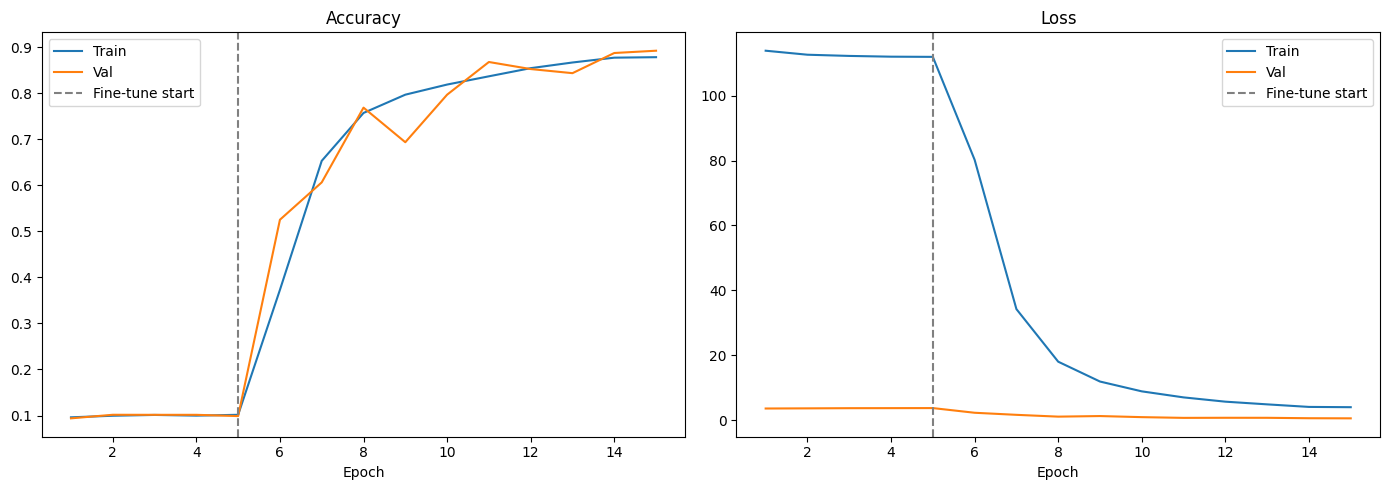

In [10]:
acc_all      = history_frozen.history['accuracy']     + history_ft.history['accuracy']
val_acc_all  = history_frozen.history['val_accuracy'] + history_ft.history['val_accuracy']
loss_all     = history_frozen.history['loss']         + history_ft.history['loss']
val_loss_all = history_frozen.history['val_loss']     + history_ft.history['val_loss']
ep           = range(1, len(acc_all) + 1)
split_ep     = len(history_frozen.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, acc_all, label='Train'); ax1.plot(ep, val_acc_all, label='Val')
ax1.axvline(x=split_ep, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(ep, loss_all, label='Train'); ax2.plot(ep, val_loss_all, label='Val')
ax2.axvline(x=split_ep, color='gray', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

---
## Evaluasi EfficientNetB0

In [11]:
val_gen.reset()
y_true, y_pred_list = [], []

for _ in range(len(val_gen)):
    X_b, y_b = next(val_gen)
    preds = model.predict(X_b, verbose=0)
    y_true.extend(np.argmax(y_b, axis=1))
    y_pred_list.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred_list)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 50)
print('  HASIL EVALUASI — EfficientNetB0')
print('=' * 50)
print(f'  Akurasi        : {acc * 100:.2f}%')
print(f'  F1-score Macro : {f1 * 100:.2f}%')
print('=' * 50)
print()
print(classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    zero_division=0
))

  HASIL EVALUASI — EfficientNetB0
  Akurasi        : 89.22%
  F1-score Macro : 83.28%

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.82      0.98      0.89       126
                                 Apple___Black_rot       1.00      0.99      1.00       124
                          Apple___Cedar_apple_rust       0.95      1.00      0.97        55
                                   Apple___healthy       0.91      0.98      0.94       329
                               Blueberry___healthy       0.92      1.00      0.96       300
          Cherry_(including_sour)___Powdery_mildew       0.96      0.98      0.97       210
                 Cherry_(including_sour)___healthy       0.98      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00       102
                       Corn_(maize)___Common_rust_       0.42      1.00      0.59   

---
## Confusion Matrix (Top 10 Kelas)

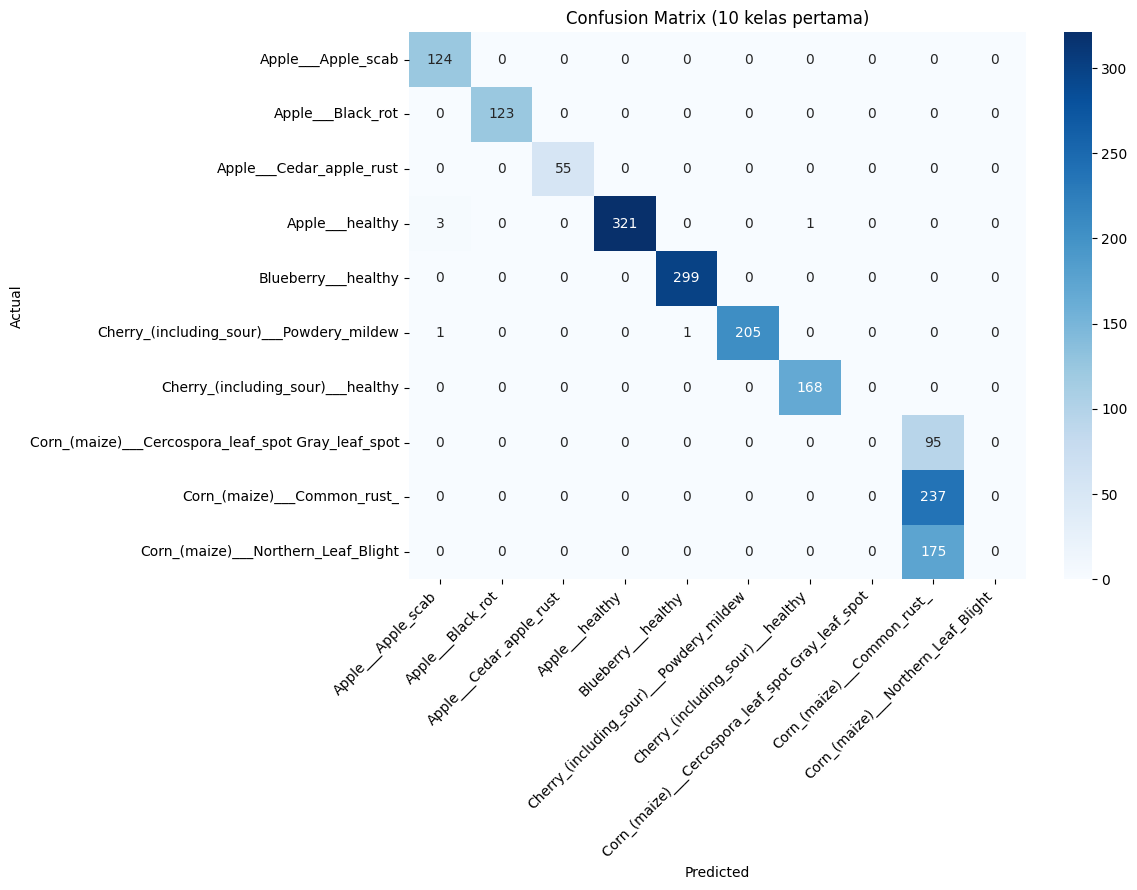

In [12]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
n_show = min(10, NUM_CLASSES)
plt.figure(figsize=(12, 9))
sns.heatmap(cm[:n_show, :n_show], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names[:n_show], yticklabels=class_names[:n_show])
plt.title('Confusion Matrix (10 kelas pertama)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Baseline: SVM + LBP dan SVM + HOG

> Hanya berjalan jika `RUN_BASELINE = True`. Butuh ~1–2 jam tambahan.

In [13]:
acc_lbp, f1_lbp = None, None
acc_hog, f1_hog = None, None

if RUN_BASELINE:
    all_paths, all_labels_int = [], []
    for idx, cls in enumerate(kelas):
        cls_dir = os.path.join(RAW_PATH, cls)
        count = 0
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.png']:
            for p in glob.glob(os.path.join(cls_dir, ext)):
                if count >= N_LIMIT_SVM: break
                all_paths.append(p); all_labels_int.append(idx); count += 1
            if count >= N_LIMIT_SVM: break
    print(f'Total citra baseline: {len(all_paths)}')

    X_lbp, X_hog_feat, y_base = [], [], []
    for i, (path, label) in enumerate(zip(all_paths, all_labels_int)):
        img = load_and_preprocess(path, size=IMG_SIZE_SVM)
        if img is None: continue
        gray = np.mean(img, axis=2)
        lbp  = skfeature.local_binary_pattern(gray, 24, 3, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)
        X_lbp.append(hist.astype(np.float32))
        feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')
        X_hog_feat.append(feat.astype(np.float32))
        y_base.append(label)
        if (i + 1) % 2000 == 0:
            print(f'  {i+1}/{len(all_paths)} selesai...')

    X_lbp = np.array(X_lbp); X_hog_feat = np.array(X_hog_feat); y_base = np.array(y_base)

    def run_svm(X, y, n_comp, label):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                               random_state=SEED, stratify=y)
        sc  = StandardScaler()
        Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)
        pca = PCA(n_components=min(n_comp, Xtr.shape[1]))
        Xtr = pca.fit_transform(Xtr); Xte = pca.transform(Xte)
        svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
        svm.fit(Xtr, ytr)
        yp  = svm.predict(Xte)
        a = accuracy_score(yte, yp)
        f = f1_score(yte, yp, average='macro', zero_division=0)
        print(f'=== {label} ===  Akurasi: {a*100:.2f}%  F1: {f*100:.2f}%')
        return a, f

    acc_lbp, f1_lbp = run_svm(X_lbp,     y_base, 26,  'SVM + LBP')
    acc_hog, f1_hog = run_svm(X_hog_feat, y_base, 256, 'SVM + HOG')

else:
    print('RUN_BASELINE = False — baseline dilewati.')

RUN_BASELINE = False — baseline dilewati.


---
## Rangkuman Perbandingan Metode

Metode                            Akurasi   F1 Macro
----------------------------------------------------
EfficientNetB0 (ours)              89.22%     83.28%


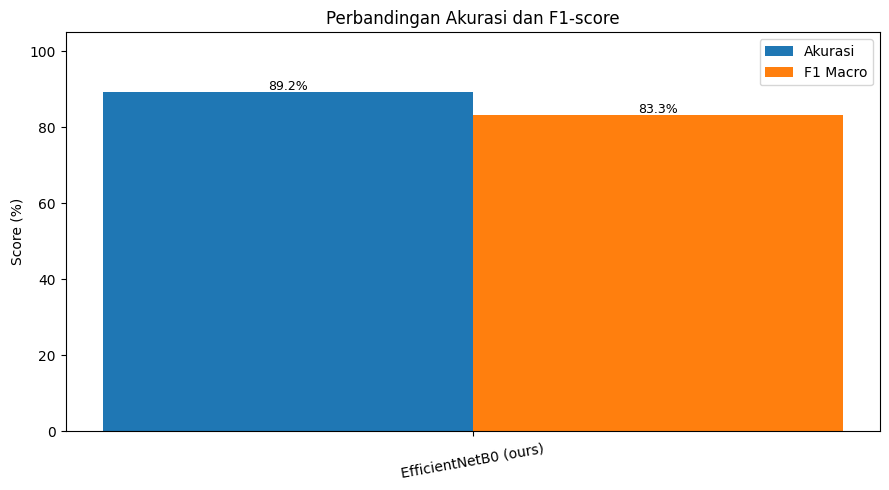

In [14]:
results = {'EfficientNetB0 (ours)': {'Akurasi': acc * 100, 'F1 Macro': f1 * 100}}
if acc_lbp is not None:
    results['SVM + LBP'] = {'Akurasi': acc_lbp * 100, 'F1 Macro': f1_lbp * 100}
if acc_hog is not None:
    results['SVM + HOG'] = {'Akurasi': acc_hog * 100, 'F1 Macro': f1_hog * 100}

print(f'{"Metode":<30} {"Akurasi":>10} {"F1 Macro":>10}')
print('-' * 52)
for method, scores in results.items():
    print(f'{method:<30} {scores["Akurasi"]:>9.2f}% {scores["F1 Macro"]:>9.2f}%')

fig, ax = plt.subplots(figsize=(9, 5))
methods  = list(results.keys())
acc_vals = [results[m]['Akurasi'] for m in methods]
f1_vals  = [results[m]['F1 Macro'] for m in methods]
x, w = np.arange(len(methods)), 0.35

ax.bar(x - w/2, acc_vals, w, label='Akurasi')
ax.bar(x + w/2, f1_vals,  w, label='F1 Macro')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=10)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 105)
ax.set_title('Perbandingan Akurasi dan F1-score'); ax.legend()
for i, v in enumerate(acc_vals):
    ax.text(i - w/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
for i, v in enumerate(f1_vals):
    ax.text(i + w/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()